In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mobile-price-classification/train.csv
/kaggle/input/mobile-price-classification/test.csv


# Project Information
## Data Information
In this data:
* id:ID
* battery_power:Total energy a battery can store in one time measured in mAh
* blue:Has bluetooth or not
* clock_speed:speed at which microprocessor executes instructions
* dual_sim:Has dual sim support or not
* fc:Front Camera mega pixels
* four_g:Has 4G or not
* int_memory:Internal Memory in Gigabytes
* m_dep:Mobile Depth in cm
* mobile_wt:Weight of mobile phone
* n_cores:Number of cores of processor
* pc:Primary Camera mega pixels
* px_height:Pixel Resolution Height
* px_width:Pixel Resolution Width
* ram:Random Access Memory in Megabytes
* sc_h:Screen Height of mobile in cm
* sc_w:Screen Width of mobile in cm
* talk_time:longest time that a single battery charge will last when you are
* three_g:Has 3G or not
* touch_screen:Has touch screen or not
* wifi:Has wifi or not

## Project Aim
In this project, a price range estimation will be made using basic phone features.

# Loading and Examining the Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,RepeatedStratifiedKFold,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score, recall_score, f1_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

In [3]:
train_df = pd.read_csv("../input/mobile-price-classification/train.csv")
test_df = pd.read_csv("../input/mobile-price-classification/test.csv")
train_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
print("Bluetooth\n",train_df.blue.value_counts())
print("Dual sim\n",train_df.dual_sim.value_counts())
print("4G\n",train_df.four_g.value_counts())
print("Number of Cores\n",train_df.n_cores.value_counts())
print("3G\n",train_df.three_g.value_counts())
print("Touch Screen\n",train_df.touch_screen.value_counts())
print("Wifi\n",train_df.wifi.value_counts())

Bluetooth
 0    1010
1     990
Name: blue, dtype: int64
Dual sim
 1    1019
0     981
Name: dual_sim, dtype: int64
4G
 1    1043
0     957
Name: four_g, dtype: int64
Number of Cores
 4    274
7    259
8    256
2    247
3    246
5    246
1    242
6    230
Name: n_cores, dtype: int64
3G
 1    1523
0     477
Name: three_g, dtype: int64
Touch Screen
 1    1006
0     994
Name: touch_screen, dtype: int64
Wifi
 1    1014
0     986
Name: wifi, dtype: int64


In [6]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [7]:
train_df.shape

(2000, 21)

In [8]:
test_df.shape

(1000, 21)

# Data Visualization

## Correlation 
Correlation is a term that is a measure of the strength of a linear relationship between two quantitative variables.Correlation coefficient has a value that must fall between -1.0 and +1.0.
* The closer correlation coefficient is to zero, the weaker the linear relationship.
* Positive correlation coefficient values indicate a positive correlation, where the values of both variables tend to increase together.
* Negative correlation coefficient values indicate a negative correlation, where the values of one variable tend to increase when the values of the other variable decrease.

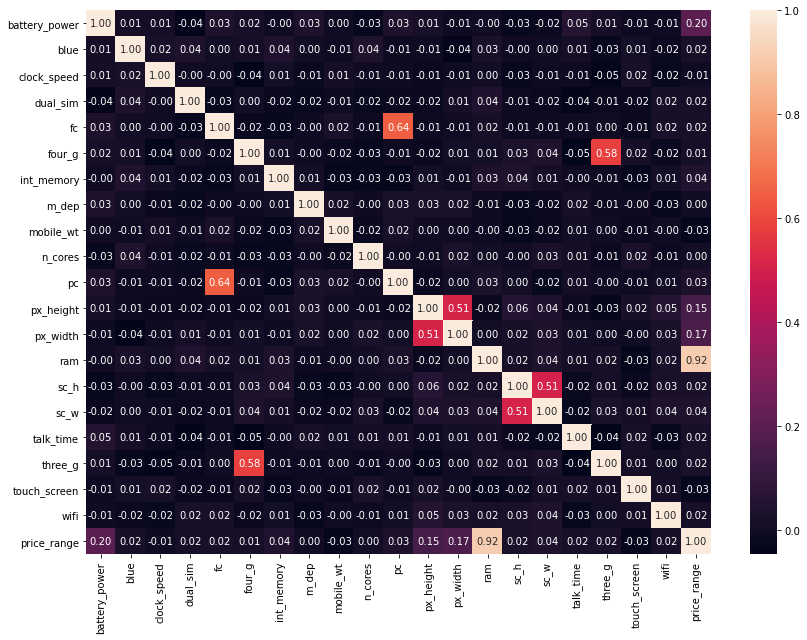

In [9]:
plt.figure(figsize=(14,10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f");

When the graph above is examined, it is seen that there is a high correlation between RAM and Price Range variables.

## Price range according to the number of processor cores and battery power

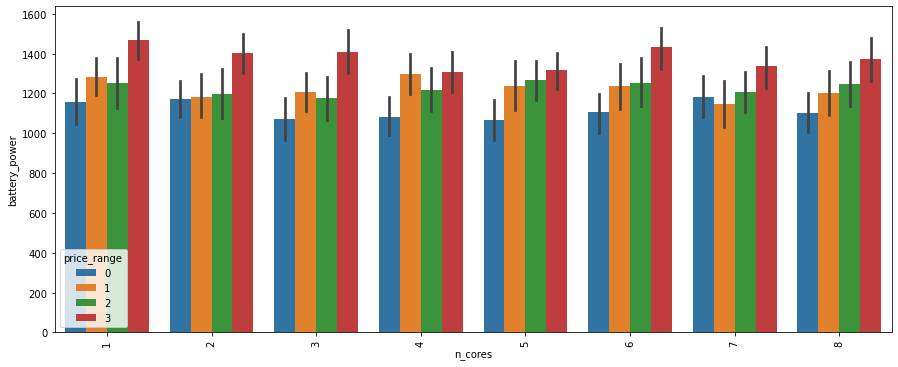

In [10]:
plt.figure(figsize=(15,6));
sns.barplot( x= "n_cores", y = "battery_power" ,hue="price_range", data=train_df)
plt.xticks(rotation=90);

## RAM vs Price Range

<AxesSubplot:xlabel='price_range', ylabel='ram'>

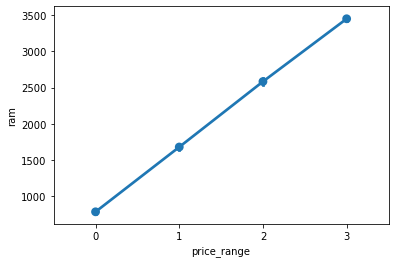

In [11]:
sns.pointplot(y="ram", x="price_range", data=train_df)

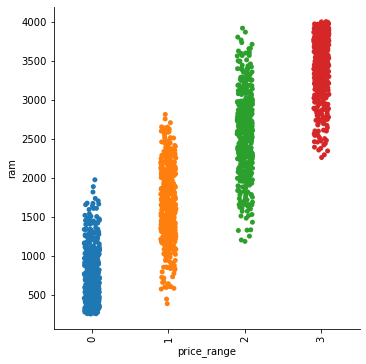

In [12]:
sns.catplot(x="price_range",y="ram",data=train_df)
plt.xticks(rotation=90);

## Internal Memory in Gigabytes vs Price Range

<AxesSubplot:xlabel='price_range', ylabel='int_memory'>

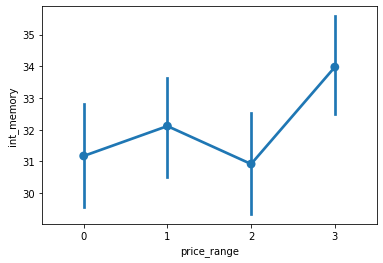

In [13]:
sns.pointplot(y="int_memory", x="price_range", data=train_df)

## Talk Time vs Price Range

<AxesSubplot:xlabel='price_range', ylabel='talk_time'>

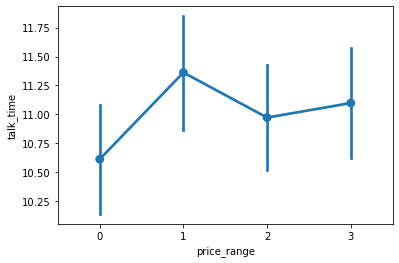

In [14]:
sns.pointplot(y="talk_time", x="price_range", data=train_df)

## Distribution of Phones Supporting 4G

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



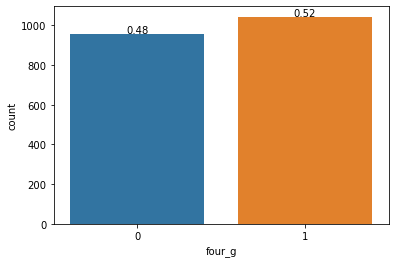

In [15]:
total = float(len(train_df))
ax = sns.countplot(train_df["four_g"]);
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center"); 

## Distribution of Phones Supporting Wifi

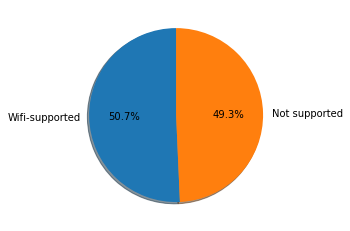

In [16]:
labels = ["Wifi-supported",'Not supported']
values=train_df['wifi'].value_counts().values
fig1, ax1 = plt.subplots()
ax1.pie(values, labels=labels, autopct='%1.1f%%',shadow=True,startangle=90)
plt.show()

## Distribution of Price Range

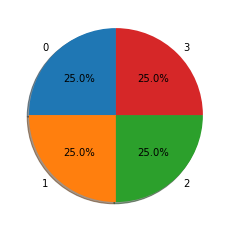

In [17]:
labels = ["0",'1',"2","3"]
values=train_df['price_range'].value_counts().values
fig1, ax1 = plt.subplots()
ax1.pie(values, labels=labels, autopct='%1.1f%%',shadow=True,startangle=90)
plt.show()

## Visualization For Outliers

In [18]:
def OutliersBox(df, nameOfFeature):
    trace0 = go.Box(y = df[nameOfFeature],
                    name = "All Points",
                    jitter = 0.3,
                    pointpos = -1.8,
                    boxpoints = "all")
    trace1 = go.Box(y = df[nameOfFeature],
                    name = "Only Whiskers",
                    boxpoints = False)
    trace2 = go.Box(y = df[nameOfFeature],
                    name = "Suspected Outliers",
                    boxpoints = "suspectedoutliers",
                    marker = dict(color = 'rgb(8,81,156)',
                                outliercolor = 'rgba(219, 64, 82, 0.6)', line = dict(outliercolor = 'rgba(219, 64, 82, 0.6)',
                                                                                   outlierwidth = 2)),
                    line = dict(color = 'rgb(8,81,156)') )
    trace3 = go.Box(y = df[nameOfFeature],
                    name = "Whiskers and Outliers",
                    boxpoints = "outliers")
    
    data_ = [trace0, trace1, trace2, trace3]
    layout_ = go.Layout(
        title = "{} Outliers".format(nameOfFeature)
    )
    fig = go.Figure(data=data_, layout = layout_)
    py.iplot(fig, filename = "Outliers")

In [19]:
OutliersBox(train_df,"talk_time")

# Machine Learning Model

## Splitting Data
Above, we first gave all variables except the "price_range" variable to the X variable and gave the variable "price_range" to the y variable. Then we split the data into train and test data. X_train and y_train show the dependent and independent variables to be used to test the model, while X_test and y_test are used to develop the model. Test_size specifies how many of data (10%) will be used for testing. Random_state is used to see the same distinction every time we run the program.

In [20]:
X = train_df.drop(["price_range"], axis=1)
y = train_df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=42)

## ML Model Function

In [21]:
def ml_model(model, parameters):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
    random_search = RandomizedSearchCV(model, parameters, cv=cv, random_state=1, n_jobs=-1, verbose=2 )
    #grid_search = GridSearchCV(model, parameters, cv=cv, n_jobs=-1, verbose=2)
    pipe = make_pipeline(StandardScaler(), PCA(n_components=0.95),random_search)
    pipe.fit(X_train, y_train)
    
    print('                 Classification report \n')

    print(classification_report(y_test, pipe.predict(X_test)))

## Logistic Regression

In [22]:
log_reg = LogisticRegression()
log_reg_params = {"C" : [1,2,3,0.01,0.001, 2.5, 1.5],
                  "max_iter" : range(100,800,100)}
ml_model(log_reg, log_reg_params)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 956 tasks      | elapsed:   17.3s


                 Classification report 

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        59
           1       0.96      0.98      0.97        49
           2       0.96      0.98      0.97        45
           3       0.98      0.96      0.97        47

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   17.6s finished


## Decision Tree

In [23]:
tree = DecisionTreeClassifier()
decTree_params = {"max_depth" : [5,10,15,20,25,30],
                  "min_samples_split" : np.arange(2,50),
                  "min_samples_leaf" : np.arange(1,50)}
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
random_search = RandomizedSearchCV(tree, decTree_params, cv=cv, random_state=1, n_jobs=-1, verbose=2 )
#grid_search = GridSearchCV(model, parameters, cv=cv, n_jobs=-1, verbose=2)
pipe = make_pipeline(random_search)
pipe.fit(X_train, y_train)
    
print('                 Classification report \n')

print(classification_report(y_test, pipe.predict(X_test)))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    1.0s


                 Classification report 

              precision    recall  f1-score   support

           0       0.98      0.88      0.93        59
           1       0.80      0.92      0.86        49
           2       0.80      0.73      0.77        45
           3       0.84      0.89      0.87        47

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.86      0.86      0.86       200



[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    6.5s finished


## KNN

In [24]:
knn = KNeighborsClassifier()
knn_params = {"n_neighbors" : np.arange(1,50),
              "leaf_size" : np.arange(1,50)}
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
random_search = RandomizedSearchCV(knn, knn_params, cv=cv, random_state=1, n_jobs=-1, verbose=2 )
#grid_search = GridSearchCV(model, parameters, cv=cv, n_jobs=-1, verbose=2)
pipe = make_pipeline(random_search)
pipe.fit(X_train, y_train)
print('                 Classification report \n')

print(classification_report(y_test, pipe.predict(X_test)))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Done  92 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 576 tasks      | elapsed:    5.9s


                 Classification report 

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        59
           1       0.94      0.96      0.95        49
           2       0.91      0.93      0.92        45
           3       0.98      0.91      0.95        47

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    9.9s finished


## Random Forest

In [25]:
forest = RandomForestClassifier()
randomForest_params = {"n_estimators" : [100,500,1000,2000],
                       "min_samples_split" : np.arange(2,30),
                       "min_samples_leaf" : np.arange(1,50),
                       "max_features" : np.arange(1,7)}
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
random_search = RandomizedSearchCV(forest, randomForest_params, cv=cv, random_state=1, n_jobs=-1, verbose=2 )
#grid_search = GridSearchCV(model, parameters, cv=cv, n_jobs=-1, verbose=2)
pipe = make_pipeline(random_search)
pipe.fit(X_train, y_train)
print('                 Classification report \n')

print(classification_report(y_test, pipe.predict(X_test)))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done 357 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 640 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed: 12.8min finished


                 Classification report 

              precision    recall  f1-score   support

           0       0.90      0.97      0.93        59
           1       0.88      0.76      0.81        49
           2       0.77      0.82      0.80        45
           3       0.89      0.89      0.89        47

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200

